In [4]:
import pandas as pd

In [ ]:
!pip install sqlalchemy pymysql

In [5]:
from sqlalchemy import create_engine

In [ ]:
engine = create_engine(
    "mysql+pymysql://root:******@*******/sales_db"
    )
db_conn= engine.connect()
print("connected Successfully")


connected Successfully


In [7]:
df = pd.read_csv('superstore_sales.csv',encoding='windows-1252')

In [8]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


In [11]:
df.columns = [c.lower().replace(' ','_').replace('-','_') for c in df.columns]

In [12]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')


In [14]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [25]:
try:
    df.to_sql('retail_sales', con=db_conn, if_exists='replace', index=False)
    print("Data loaded successfully into 'retail_sales' table!")
except Exception as e:
    print(f"Error: {e}")

Data loaded successfully into 'retail_sales' table!


In [ ]:
!pip install matplotlib seaborn


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [24]:
def run_query(query):
    return pd.read_sql(query, db_conn)

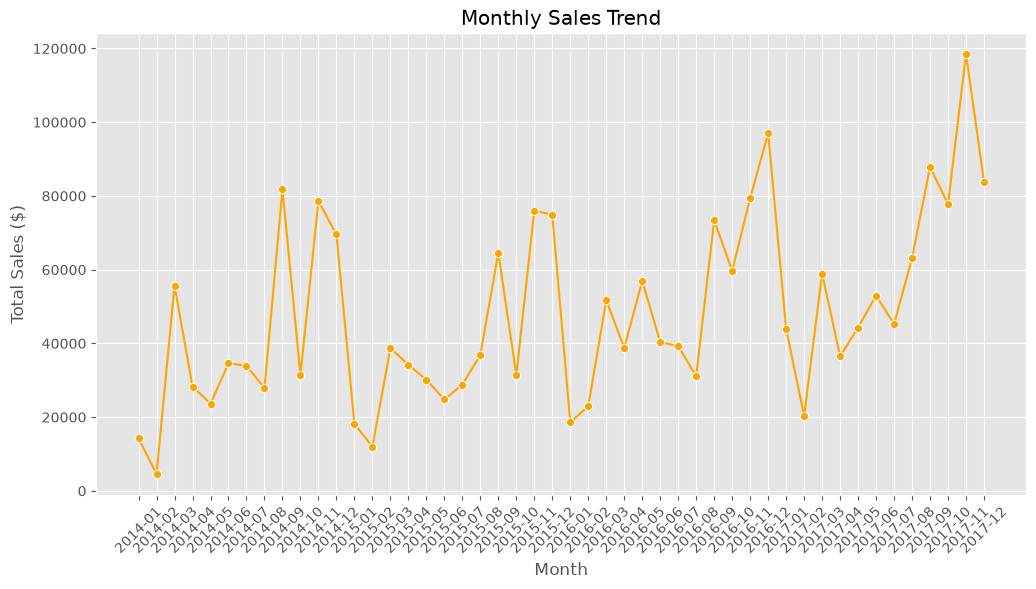

In [26]:
query_trend = """
SELECT DATE_FORMAT(order_date, '%%Y-%%m') AS month_year, SUM(sales) AS monthly_sales
FROM retail_sales
GROUP BY month_year
ORDER BY month_year;
"""
df_trend = run_query(query_trend)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trend, x='month_year', y='monthly_sales', marker='o', color='orange')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.grid(True)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14092\2271676270.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x='category', y='total_sales', palette='Set1')


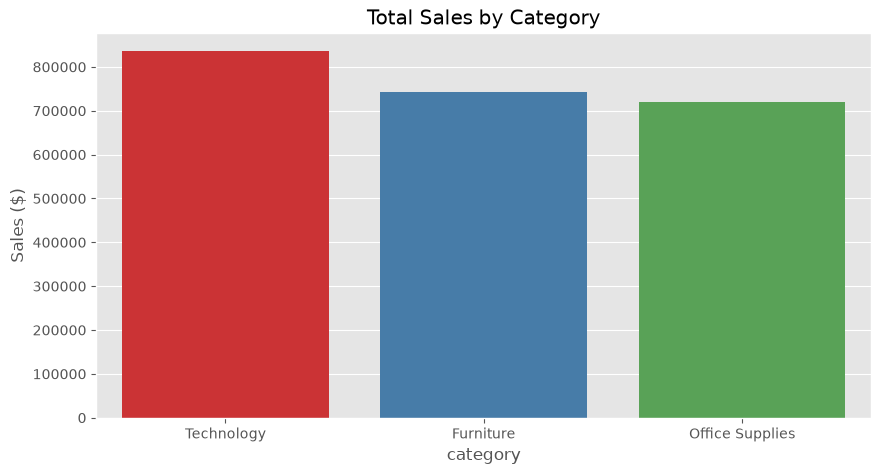

In [33]:
query_cat = """
SELECT category, SUM(sales) AS total_sales
FROM retail_sales
GROUP BY category
ORDER BY total_sales DESC;
"""
df_cat = run_query(query_cat)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_cat, x='category', y='total_sales', palette='Set1')
plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')
plt.show()

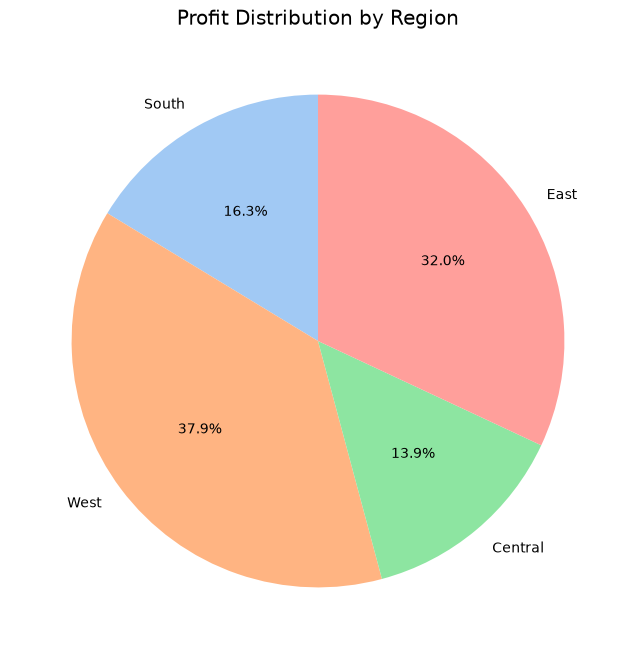

In [35]:
query_region = """
SELECT region, SUM(profit) AS total_profit
FROM retail_sales
GROUP BY region;
"""
df_region = run_query(query_region)

plt.figure(figsize=(8, 8))
plt.pie(df_region['total_profit'], labels=df_region['region'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Profit Distribution by Region')
plt.show()

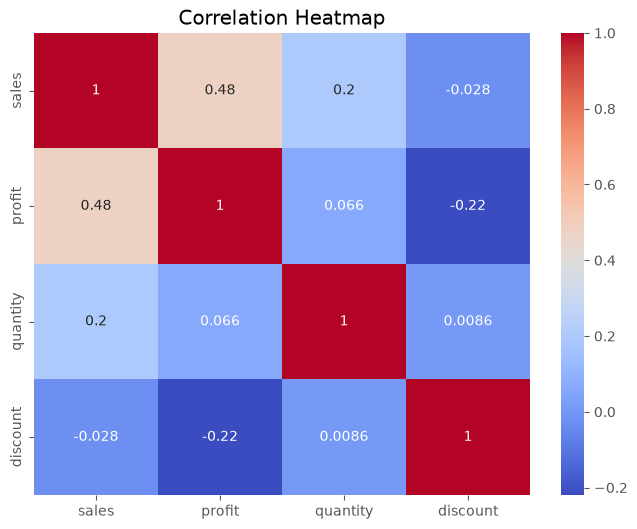

In [36]:
query_corr = """
SELECT sales, profit, quantity, discount
FROM retail_sales;
"""

df_corr = run_query(query_corr)

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()